# Citation paper classification with cora

prebuild dataset - cora
these paper contains specific research papers and citation relationships btn those papers

we represent dataset as graphs

Package installation 

pytorch lib - Planetoid ( datasets can be imported using this )

Name  | #nodes  | #edges |  #features | #classes
      
Cora  | 2,708 |  10,556 |  1,433   |  7

In [20]:
# & "C:\Users\YASHASH RAVI\AppData\Local\Programs\Python\Python311\python.exe" -m pip install torch torch-geometric scikit-learn pandas networkx    
# & "C:\Users\YASHASH RAVI\AppData\Local\Programs\Python\Python311\python.exe" -m pip install torch-geometric

import numpy as np 
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [21]:
from torch_geometric.datasets import Planetoid 

# load cora citation graph
Planetoid is the PyTorch Geometric dataset wrapper for Cora, CiteSeer, and PubMed [4]. Each paper is a node, each citation is an
edge,
x contains node features, and
y contains topic labels. The provided masks define the train, validation, and test nodes.

In [22]:
dataset = Planetoid(root="data/Planetoid",name="cora")

In [23]:
dataset
# cora()

data = dataset[0]
print(data)
# Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

# so here x = [2708, 1433] - [nodes,features]

# nodes / papers
print(data.num_nodes)

# citation
print(data.num_edges)

# features
print(data.num_node_features)

# topics 
print(dataset.num_classes)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
2708
10556
1433
7


In [24]:
# training
# Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

print(data.train_mask.sum())
print(data.val_mask.sum())
print(data.test_mask.sum())

tensor(140)
tensor(500)
tensor(1000)


how does the nodes connectes to each pther

if a is cnnected to 4 other nodes then -> (degree of A =  4)

# check data Balancing 

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
0    351
1    217
2    418
3    818
4    426
5    298
6    180
Name: count, dtype: int64


<Axes: xlabel='None', ylabel='count'>

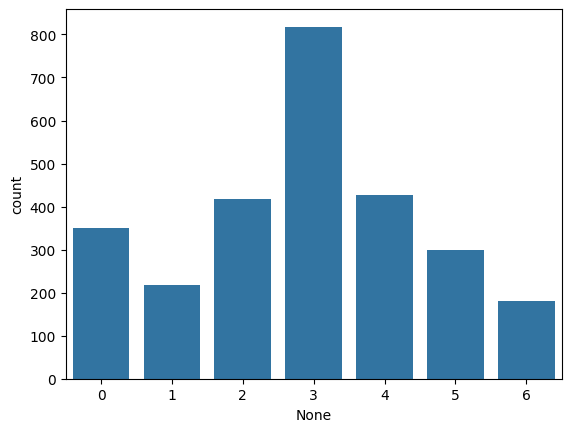

In [35]:
print(data)

# y = data.y
# tenser data
# convert tenser data to numpy

topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()
print(topic_counts)  
# labels - 7 
topic_index = topic_counts.index
topic_index


sns.barplot(x=topic_index,y=topic_counts)

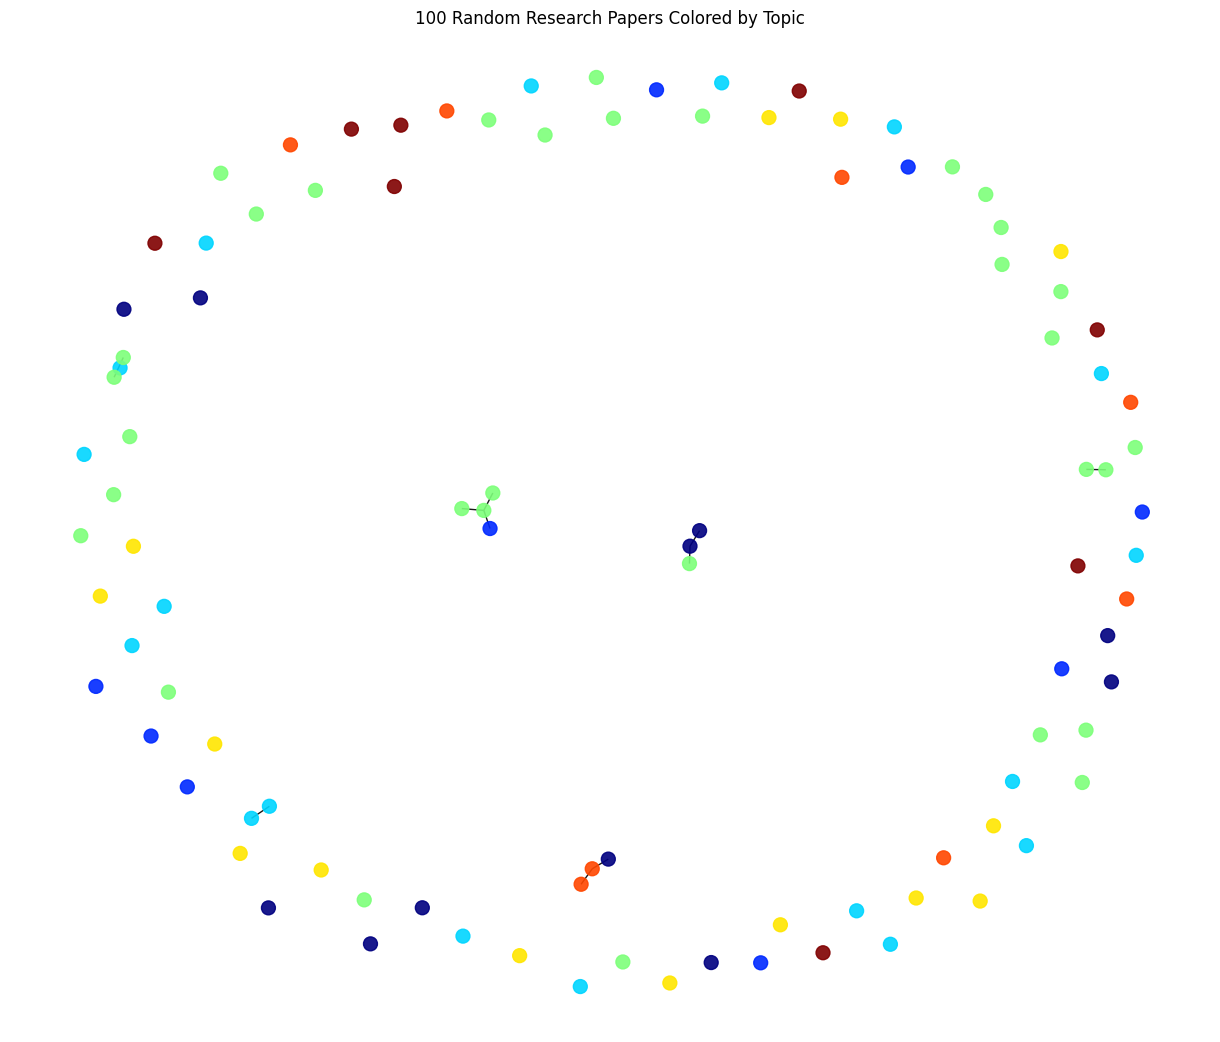

In [36]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

# Baseline: TF-IDF-style features plus Random Forest

In [37]:

X_binary = data.x.numpy()
y = data.y.numpy()

In [43]:
#Reweight the supplies word indicators.
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf #Features

train_idx = data.train_mask.numpy() #Training Research Papers
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train , y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx],y[test_idx]

rf = RandomForestClassifier(n_estimators=100,max_features='sqrt',class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
rf.predict(X_test)


array([0, 4, 2, 2, 2, 3, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 2, 4, 2,
       2, 2, 0, 4, 2, 5, 2, 2, 2, 2, 4, 0, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 1, 3, 1, 1, 1, 1, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 4, 1, 1, 4, 1, 0, 6, 3, 4, 4, 4,
       5, 1, 3, 3, 1, 0, 3, 0, 2, 1, 0, 4, 4, 1, 3, 3, 2, 4, 4, 4, 6, 3,
       3, 3, 4, 3, 3, 3, 5, 4, 4, 5, 5, 0, 3, 4, 4, 2, 1, 6, 6, 1, 0, 0,
       0, 0, 5, 0, 3, 0, 4, 0, 3, 6, 6, 4, 3, 3, 3, 4, 4, 1, 4, 4, 3, 3,
       3, 3, 4, 3, 3, 4, 4, 4, 4, 6, 3, 3, 3, 3, 3, 3, 3, 5, 1, 5, 5, 5,
       5, 4, 4, 3, 4, 1, 0, 4, 1, 2, 3, 2, 5, 5, 0, 1, 6, 5, 5, 5, 5, 0,
       4, 3, 4, 0, 1, 0, 4, 4, 0, 0, 0, 6, 0, 0, 0, 0, 0, 2, 3, 4, 0, 0,
       3, 4, 1, 3, 2, 3, 0, 3, 4, 2, 2, 4, 4, 3, 5, 0, 3, 3, 3, 3, 4, 3,
       3, 4, 4, 5, 4, 5, 5, 4, 5, 5, 5, 4, 5, 3, 4, 4, 4, 4, 4, 4, 4, 4,
       6, 6, 5, 0, 6, 3, 5, 1, 1, 0, 5, 0, 5, 0, 3, 3, 3, 1, 3, 1, 4, 3,
       3, 6, 3, 3, 5, 3, 3, 4, 3, 0, 3, 1, 3, 3, 3,

# Evaluations